# Monte Carlo simulation
***
This is a monte carlo style simulation, based on a random sampling of events, in this case, randomly-generated sheep eating and grass growing.

## Imports
***

In [1]:
import random
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp

## Rate constants
***
The experimentally measured values for k and R.

In [2]:
R = 0.00888
K = 0.00772

Now that we have these values, we can plug them into the formula we derived earlier:

$D=\frac{k}{2R}=\frac{0.00772}{2*0.00888}=0.434$

According to the theory, this should be the optimal density of sheep.

## The simulation for the fast farmer
***
We'll be assuming a 1000-block pasture. We'll define a function that takes the sheep population as an input so we can test whatever sheep density we want. We'll also let the function take as an input the number of seconds to simulate.

We'll use a time step of 1 second.

In [1]:
def monteCarloFF(sheep_num, iter):

    AX_g = 1000 #the total number of grass blocks in the pasture - initially AX_g = A

    eats_list = [] #how many blocks were eaten by sheep on each tick
    grass_list = [] #grass population of the pasture on each tick
    
    for i in range(0, iter):
        #number of successful sheep eating attempts
        #binomial variate with success probability of R * grass fraction
        eats = sp.stats.binom.rvs(sheep_num, AX_g/1000 * R)
        AX_g -= eats

        #grass growth
        AX_g += sp.stats.binom.rvs(AX_g, K * (1 - AX_g/1000))
    
        eats_list.append(eats)
        grass_list.append(AX_g)
    return np.array(eats_list), np.array(grass_list)

Because we're dealing with a 1000-block pasture, the optimal sheep population should be 434. We'll run simulations with that population, and a few others.

completed sim with sheep_num = 135
completed sim with sheep_num = 435
completed sim with sheep_num = 735


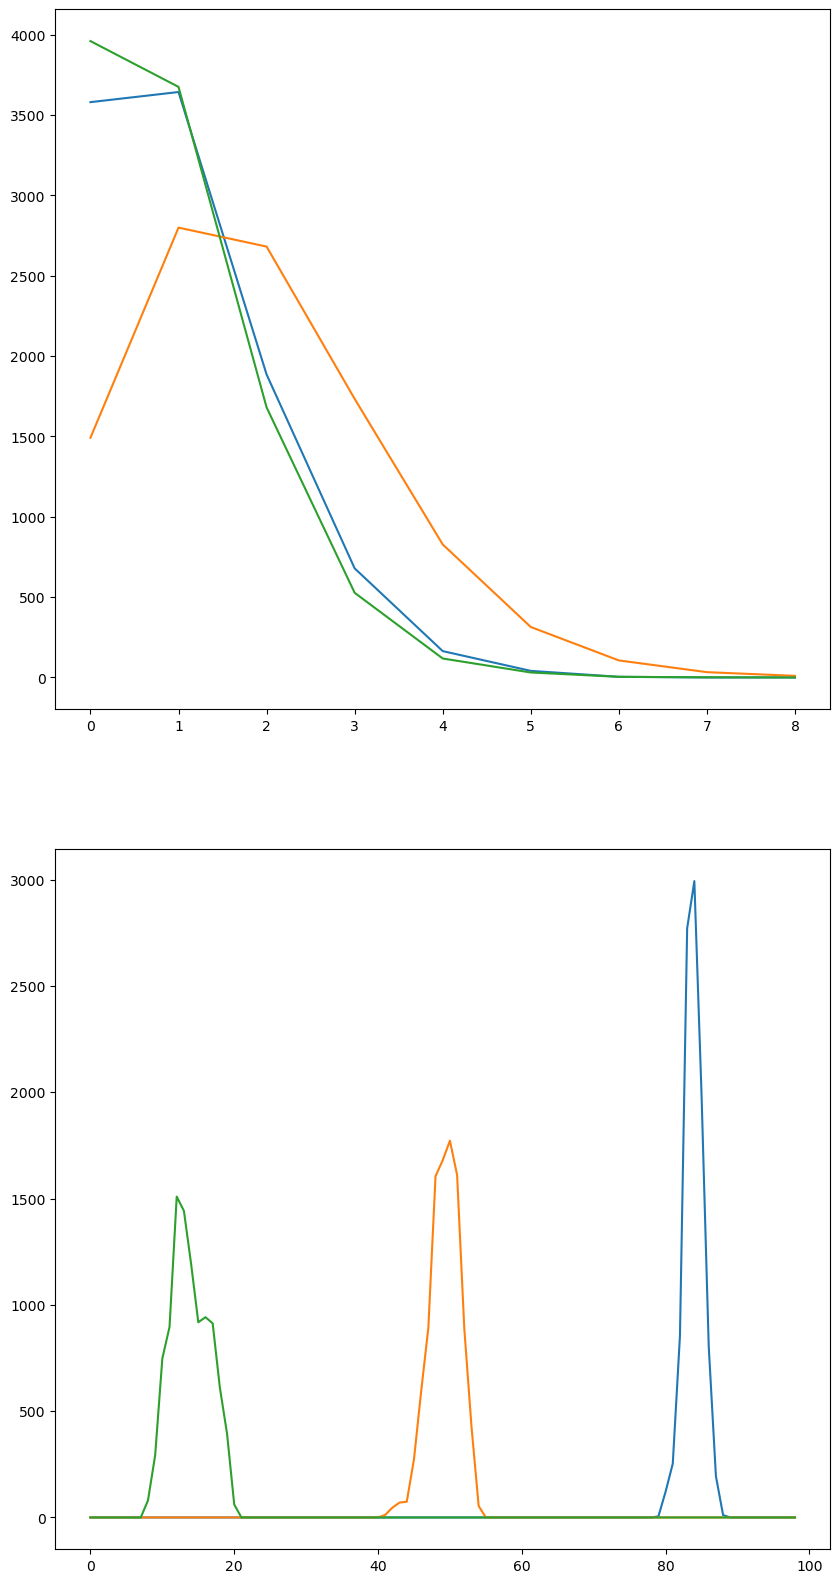

In [29]:
iters = 20000

f, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,20))

def monteCarloFFStats(sheep_num, iter, a_eats, a_grass):
    eats, grass = monteCarloFF(sheep_num, iter)
    print("completed sim with sheep_num = {0}".format(sheep_num))
    a_eats.plot(np.histogram(eats[int(iter/2):iter-1], bins=np.arange(0,10))[0])
    a_grass.plot(np.histogram(grass[int(iter/2):iter-1], bins=np.arange(0,1000,10))[0])

for i in [135, 435, 735]:
    monteCarloFFStats(i, iters, axs[0], axs[1])

plt.show()

## Simulation for the slow farmer
***
This is gonna look pretty much the same as the fast farmer, but it will also output the wool harvest every T seconds.

In [7]:
def monteCarloFS(sheep_num, iter, T):

    AX_g = 1000 #the total number of grass blocks in the pasture - initially AX_g = A
    N_w = 0 #total number of sheep with wool - initially 0

    eats_list = [] #how many blocks were eaten by sheep on each tick
    grass_list = [] #grass population of the pasture on each tick
    harvest_list = [] #how many sheep were sheared on each harvest
    wool_list = []
    
    for i in range(0, iter):
        #number of successful sheep eating attempts
        #binomial variate with success probability of R * grass fraction
        eats = sp.stats.binom.rvs(sheep_num, AX_g/1000 * R)
        AX_g -= eats
        N_w += sp.stats.binom.rvs(sheep_num-N_w, eats/sheep_num)

        #grass growth
        AX_g += sp.stats.binom.rvs(AX_g, K * (1 - AX_g/1000))
    
        eats_list.append(eats)
        grass_list.append(AX_g)
        wool_list.append(N_w)
        if i%T == 0:
            harvest_list.append(N_w)
            N_w=0
        
    return np.array(eats_list), np.array(grass_list), np.array(harvest_list), np.array(wool_list)

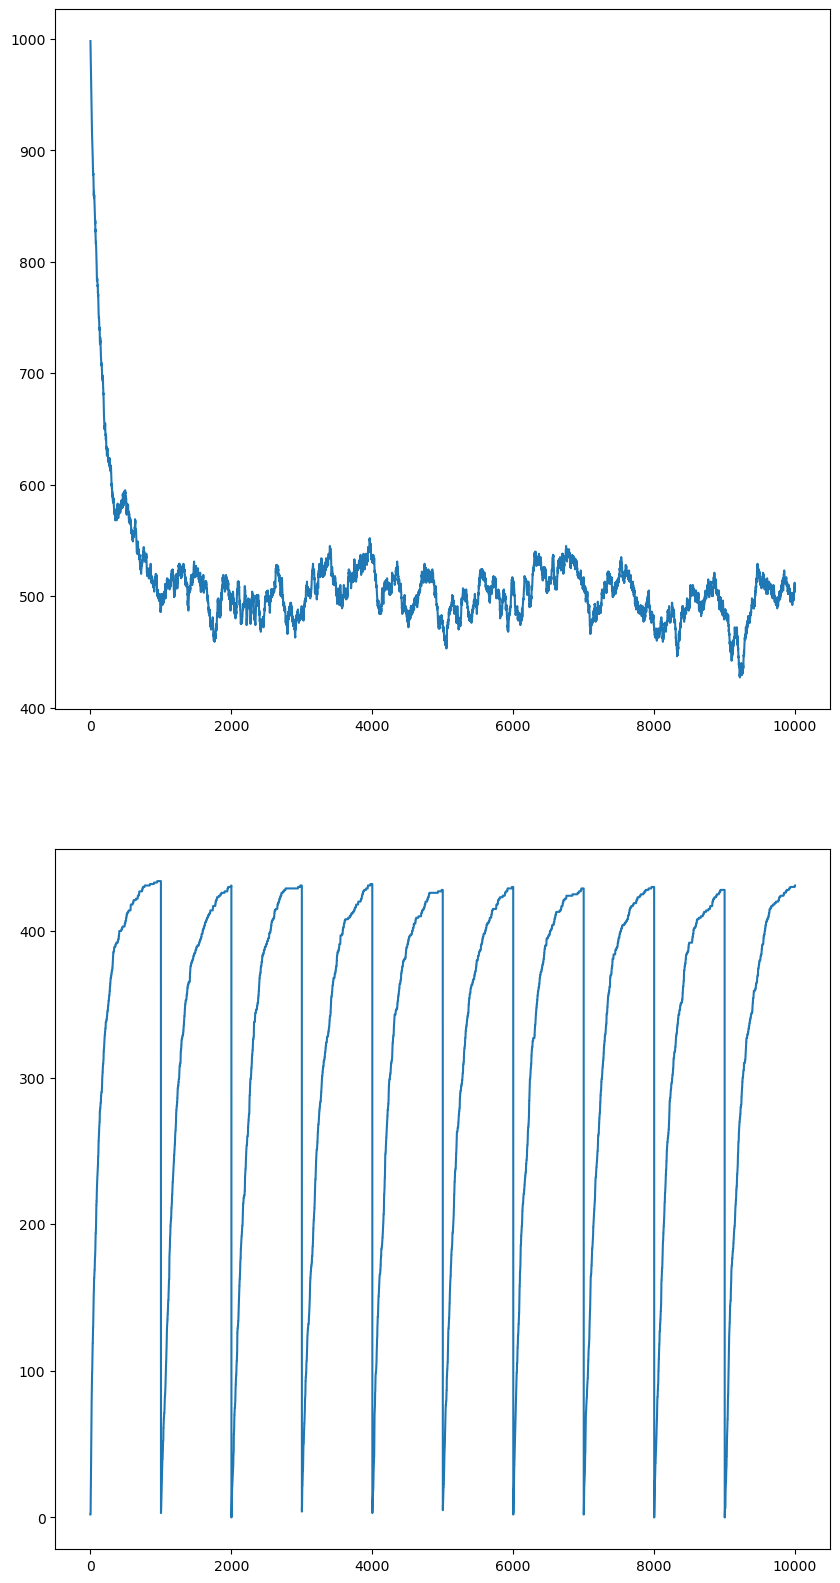

In [24]:
results = monteCarloFS(435, 10000, 1000)

f, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,20))

axs[0].plot(results[1])
axs[1].plot(results[3])

plt.show()